# BMM411 — Biomedical Image Processing
# Assignment 2: Spatial & Frequency Domain Filtering

| | |
|---|---|
| **Name** | Sıla Dilda Erdoğan |
| **Student ID** | 211701035 |
| **GitHub Username** | silaerdgn |

> Oral defense sessions may be held without prior notice.
> **Minimum 5 commits** on GitHub Classroom. Single-commit submissions: −20 points.

| Part | Topic | Points |
|------|-------|--------|
| 2 | Spatial Filtering | 45 |
| 3 | Frequency Domain Filtering | 40 |
| 4 | Clinical Discussion | 15 |
| Bonus | Notch Filter | +10 |

**Total: 100 + 10 Bonus**


---
## Background

Read before writing any code. These are the formulas you will implement.

---

### Convolution

$$g(x,y) = \sum_s \sum_t f(x-s,\,y-t)\cdot h(s,t)$$

Convolution flips the kernel 180° before sliding. For symmetric kernels (box, Gaussian) this equals correlation.
Padding handles borders: *zero* (fill with 0) or *replicate* (repeat edge pixel).

---

### Smoothing Kernels

**Box:** $h_{box}[i,j] = 1/k^2$ for all $(i,j)$ in a $k\times k$ window (normalised).

**Gaussian:** $h_G[i,j] = \exp\!\left(-\dfrac{i^2+j^2}{2\sigma^2}\right)$, normalised.
Kernel size $= 2\lceil 3\sigma \rceil + 1$.

**Laplacian sharpening:** $\text{sharp} = f - \nabla^2 f$

**Unsharp masking:** $\text{sharp} = f + k\,(f - f_{\text{blur}})$

---

### Fourier Transform

$$F(u,v) = \sum_x\sum_y f(x,y)\,e^{-j2\pi(ux/M+vy/N)}$$

- **Magnitude** $|F|$: strength of each frequency (contrast at that scale)
- **Phase** $\angle F$: spatial location of frequencies (structural information)

Visualise magnitude as $20\log_{10}(1+|F|)$.

---

### Frequency-Domain Filters

Apply as: $g = \mathcal{F}^{-1}\{H(u,v)\cdot F(u,v)\}$, where $D$ = distance from DC centre.

| Filter | $H_{LP}(u,v)$ |
|--------|--------------|
| Ideal (ILPF) | $1$ if $D\le D_0$, else $0$ |
| Butterworth (BLPF) | $1\,/\,(1+(D/D_0)^{2n})$ |
| Gaussian (GLPF) | $\exp(-D^2/2D_0^2)$ |

High-pass: $H_{HP} = 1 - H_{LP}$

HFE: $H_{\text{HFE}} = 0.5 + 2.0\cdot H_{HP}^{\text{Butter}}$


---
## Part 0 — Setup

Enter your student ID below. All personalised parameters are derived from it.
> **Required files:** `xray.dcm` and `mri.dcm` must be in the same folder as this notebook.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math

STUDENT_ID = 211701035   # <-- enter your 9-digit student ID
assert STUDENT_ID != 0, "Enter your student ID!"

rng = np.random.RandomState(STUDENT_ID)
MY_KERNEL = int(rng.choice([3, 5, 7]))
MY_SIGMA  = round(float(rng.uniform(0.8, 2.5)), 1)
MY_K      = round(float(rng.uniform(0.8, 2.0)), 1)
MY_D0_LP  = int(rng.randint(20, 55))
MY_D0_HP  = int(rng.randint(20, 55))
MY_N      = int(rng.choice([1, 2, 4]))
MY_NOISE  = int(rng.randint(12, 28))

print(f"MY_KERNEL={MY_KERNEL}  MY_SIGMA={MY_SIGMA}  MY_K={MY_K}")
print(f"MY_D0_LP={MY_D0_LP}  MY_D0_HP={MY_D0_HP}  MY_N={MY_N}  MY_NOISE={MY_NOISE}")


MY_KERNEL=7  MY_SIGMA=1.6  MY_K=1.7
MY_D0_LP=44  MY_D0_HP=45  MY_N=4  MY_NOISE=21


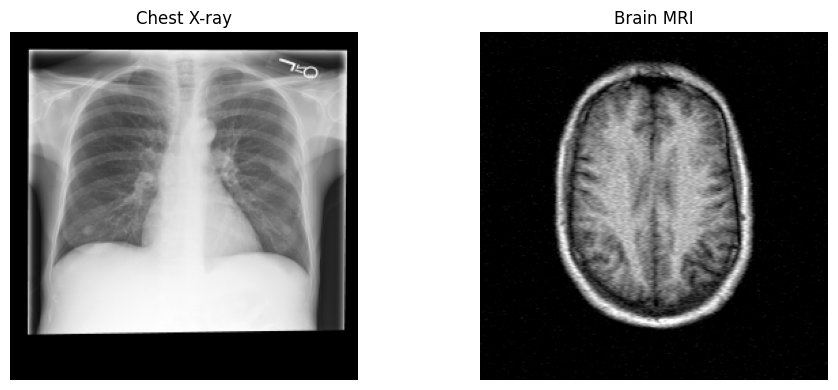

xray: (256, 256)  brain: (256, 256)


In [4]:
import pydicom, cv2

def dicom_to_uint8(path, size=(256, 256)):
    dcm = pydicom.dcmread(path)
    px  = dcm.pixel_array.astype(np.float32)
    px  = px * float(getattr(dcm, 'RescaleSlope', 1)) + float(getattr(dcm, 'RescaleIntercept', 0))
    wc  = float(getattr(dcm, 'WindowCenter', (px.max()+px.min())/2))
    ww  = float(getattr(dcm, 'WindowWidth',   px.max()-px.min()))
    if hasattr(wc, '__iter__'): wc = float(list(wc)[0])
    if hasattr(ww, '__iter__'): ww = float(list(ww)[0])
    px  = np.clip((px - (wc-ww/2)) / ww * 255, 0, 255).astype(np.uint8)
    return cv2.resize(px, size, interpolation=cv2.INTER_AREA)

xray  = dicom_to_uint8("xray.dcm")
brain = dicom_to_uint8("mri.dcm")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(xray,  cmap='gray'); ax[0].set_title('Chest X-ray');  ax[0].axis('off')
ax[1].imshow(brain, cmap='gray'); ax[1].set_title('Brain MRI');    ax[1].axis('off')
plt.tight_layout(); plt.show()
print(f"xray: {xray.shape}  brain: {brain.shape}")


---
## Part 2 — Spatial Domain Filtering (45 points)


### Task 2.1 — Manual 2D Convolution (15 points)

Implement `convolve2d(image, kernel, padding)` from scratch using NumPy only.

Steps:
1. Flip the kernel 180° (both axes)
2. Pad the image according to the padding mode
3. For each output pixel, extract the neighbourhood patch and compute the weighted sum

**Forbidden:** `cv2.filter2D`, `scipy.signal.convolve2d`, `scipy.ndimage.convolve`


In [12]:
def convolve2d(image, kernel, padding='zero'):
    """
    2D spatial convolution from scratch (NumPy only).
    padding: 'zero' | 'replicate'
    Returns: float64 array, same shape as image.
    """
    image  = np.array(image,  dtype=np.float64)
    kernel = np.array(kernel, dtype=np.float64)

    kH, kW = kernel.shape
    pH, pW = kH // 2, kW // 2   # pad amount on each side (e.g. 3×3 kernel → pad 1)

    # Step 1: Flip the kernel 180° on both axes
    # Tip: use slicing  arr[::-1, ::-1]
    kernel_flipped =  kernel[::-1, ::-1]  # YOUR CODE

    # Step 2: Pad the image so output has the same shape as input
    # Use np.pad with mode='constant' (zero) or mode='edge' (replicate)
    if padding == 'zero':
        img_padded = np.pad(image, ((pH, pH), (pW, pW)), mode='constant')
    elif padding == 'replicate':
        img_padded = np.pad(image, ((pH, pH), (pW, pW)), mode='edge')
    else:
        raise ValueError("padding must be 'zero' or 'replicate'")

    # Step 3: Slide the kernel over the image and compute the dot product at each position
    H, W = image.shape
    output = np.zeros((H, W), dtype=np.float64)
    for i in range(H):
        for j in range(W):
            patch = img_padded[i:i+kH, j:j+kW]   # neighbourhood window
            output[i, j] = np.sum(patch * kernel_flipped)  # YOUR CODE: sum of patch * kernel_flipped

    return output


In [13]:
# ── Tests — DO NOT MODIFY ────────────────────────────────────────────────────
from scipy.signal import convolve2d as _sci

_img = np.arange(25, dtype=np.float64).reshape(5, 5) * 10
_k   = np.array([[1,2,1],[2,4,2],[1,2,1]], dtype=np.float64) / 16

# identity kernel must return the original
_eye = np.array([[0,0,0],[0,1,0],[0,0,0]], dtype=np.float64)
assert np.max(np.abs(convolve2d(_img, _eye) - _img)) < 1e-10,     "Identity kernel should return the input unchanged"

# zero-padding must match scipy
_my  = convolve2d(_img, _k, padding='zero')
_ref = _sci(_img, _k, mode='same', boundary='fill', fillvalue=0)
assert np.max(np.abs(_my - _ref)) < 1e-10,     f"Zero-padding mismatch: {np.max(np.abs(_my-_ref)):.2e}"

# output shape must equal input shape
assert convolve2d(_img, _k).shape == _img.shape, "Output shape must match input"

# replicate mode must not raise
try:
    convolve2d(_img, _k, padding='replicate')
except Exception as e:
    raise AssertionError(f"replicate padding raised: {e}")

print("Task 2.1 PASSED ✓")


Task 2.1 PASSED ✓


### Task 2.2 — Smoothing Filters (15 points)

Implement `box_kernel(size)` and `gaussian_kernel(sigma)` using the formulas in the Background section.
Apply both filters to each image with the parameter variants listed below and display the results.

| Filter | Variants |
|--------|----------|
| Box | 3×3, `MY_KERNEL`×`MY_KERNEL`, 11×11 |
| Gaussian | σ = `MY_SIGMA`, `MY_SIGMA*2`, `MY_SIGMA*3` |

**Analysis:** At which size / σ does blurring start to destroy clinically relevant detail?


When the images are examined, it can be observed that clinically relevant details start to deteriorate after the 7×7 size in the box filter and after σ = 3.2 in the Gaussian filter. The greatest loss of detail occurs at 11×11 for the box filter and σ = 4.8 for the Gaussian filter.

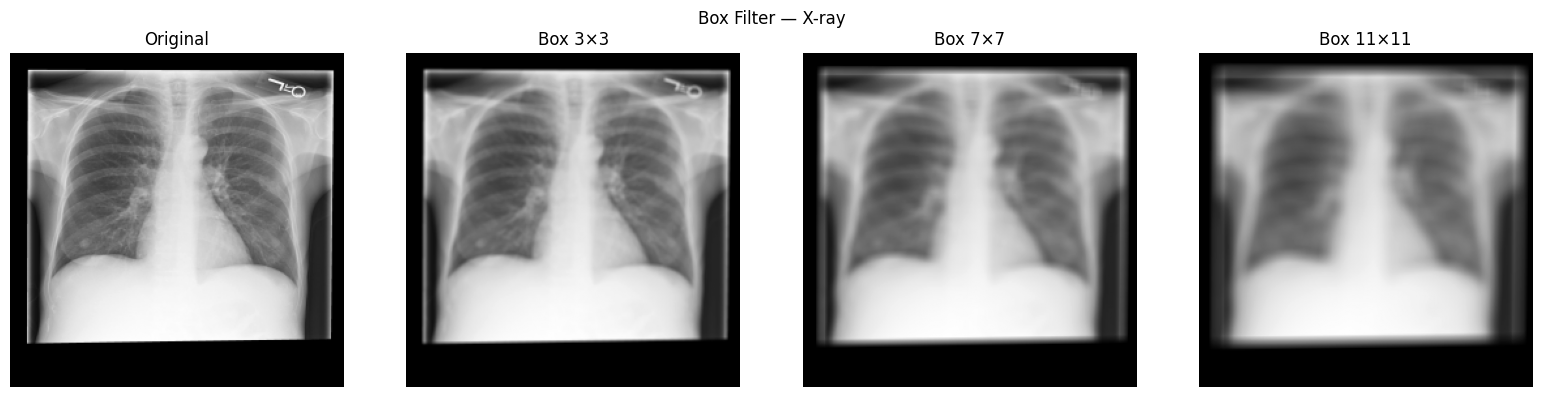

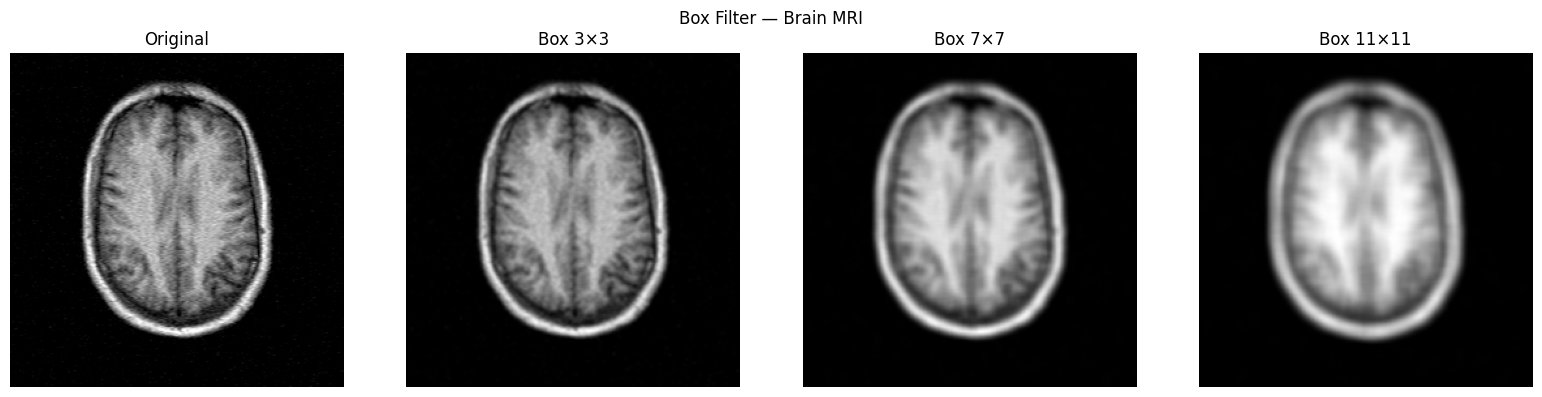

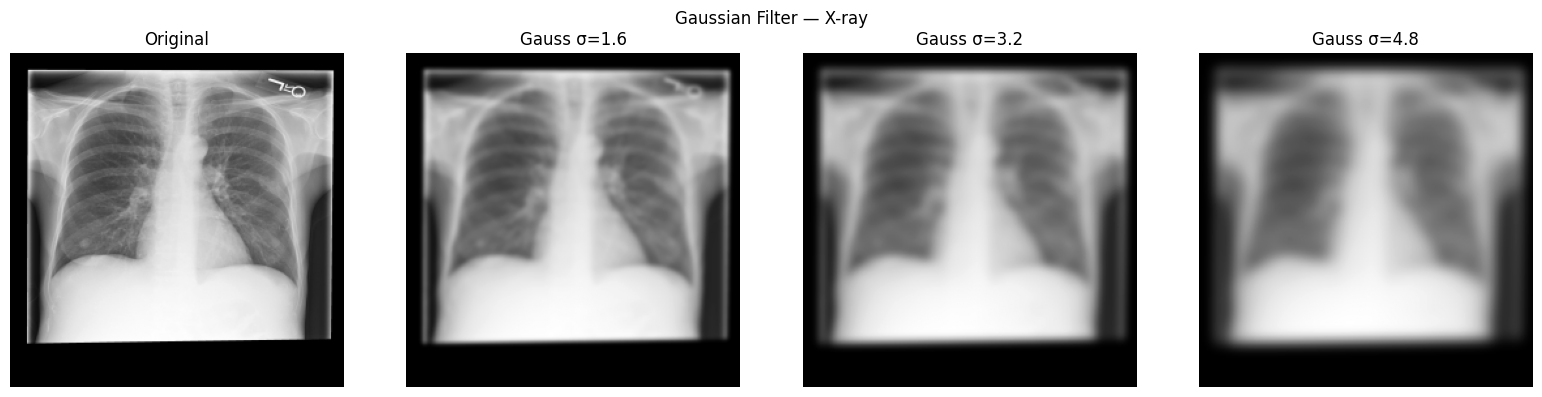

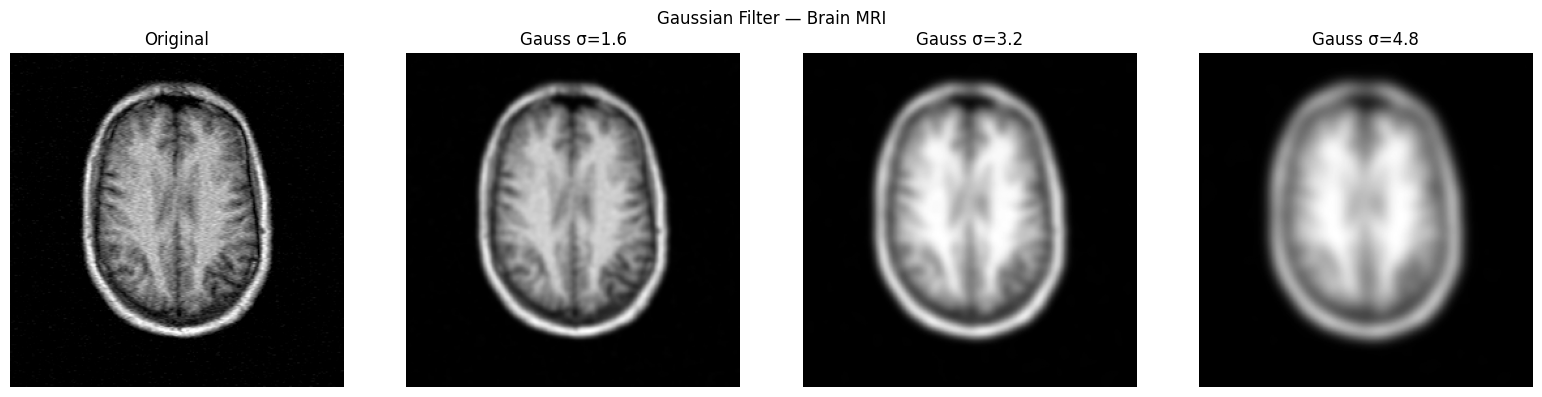

In [27]:
def box_kernel(size):
    """Return a normalised size×size box filter kernel (all values equal, sum = 1)."""
    return np.ones((size, size), dtype=np.float64) / (size * size) # YOUR CODE — hint: np.ones((size, size)) / (size * size)
    

def gaussian_kernel(sigma):
    """
    Return a normalised Gaussian kernel.
    Kernel size = 2*ceil(3*sigma) + 1
    Steps:
      1. half = int(math.ceil(3 * sigma))  →  size = 2*half + 1
      2. coords = np.arange(-half, half+1)  →  build 2D grids with np.meshgrid
      3. Apply: kernel = exp(-(X**2 + Y**2) / (2 * sigma**2))
      4. Normalise: kernel /= kernel.sum()
    """
    half = int(math.ceil(3 * sigma))
    coords = np.arange(-half, half + 1, dtype=np.float64)
    X, Y = np.meshgrid(coords, coords)
    kernel = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    kernel /= kernel.sum()
    return kernel
    


# ── Plotting code (provided — do not modify) ─────────────────────────────────
def _apply(img, kern):
    return np.clip(convolve2d(img, kern), 0, 255).astype(np.uint8)

def _show_row(images, titles, suptitle):
    fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 4))
    for ax, img, t in zip(axes, images, titles):
        ax.imshow(img, cmap='gray'); ax.set_title(t); ax.axis('off')
    plt.suptitle(suptitle); plt.tight_layout(); plt.show()

# Box filter — 3 sizes × 2 images
for img, name in [(xray, 'X-ray'), (brain, 'Brain MRI')]:
    sizes = [3, MY_KERNEL, 11]
    imgs  = [img] + [_apply(img, box_kernel(k)) for k in sizes]
    titles = ['Original'] + [f'Box {k}×{k}' for k in sizes]
    _show_row(imgs, titles, f'Box Filter — {name}')

# Gaussian filter — 3 sigmas × 2 images
for img, name in [(xray, 'X-ray'), (brain, 'Brain MRI')]:
    sigmas = [MY_SIGMA, round(MY_SIGMA * 2, 1), round(MY_SIGMA * 3, 1)]
    imgs   = [img] + [_apply(img, gaussian_kernel(s)) for s in sigmas]
    titles = ['Original'] + [f'Gauss σ={s}' for s in sigmas]
    _show_row(imgs, titles, f'Gaussian Filter — {name}')


In [28]:
# ── Tests — DO NOT MODIFY ────────────────────────────────────────────────────
for sz in [3, 5, 7]:
    bk = box_kernel(sz)
    assert bk.shape == (sz, sz),           f"box_kernel({sz}): wrong shape"
    assert abs(bk.sum() - 1.0) < 1e-10,   f"box_kernel({sz}): must sum to 1"
    assert np.allclose(bk, bk[0, 0]),     f"box_kernel({sz}): all elements must be equal"

for sig in [1.0, MY_SIGMA, 2.0]:
    gk = gaussian_kernel(sig)
    assert gk.shape[0] == gk.shape[1],              f"gaussian_kernel({sig}): must be square"
    assert gk.shape[0] % 2 == 1,                    f"gaussian_kernel({sig}): size must be odd"
    assert abs(gk.sum() - 1.0) < 1e-6,              f"gaussian_kernel({sig}): must sum to 1"
    cy, cx = gk.shape[0]//2, gk.shape[1]//2
    assert gk[cy, cx] == gk.max(),                  f"gaussian_kernel({sig}): centre must be max"
    assert np.allclose(gk, gk[::-1, :]),             f"gaussian_kernel({sig}): must be vertically symmetric"
    assert np.allclose(gk, gk[:, ::-1]),             f"gaussian_kernel({sig}): must be horizontally symmetric"

# Applying box kernel to a constant image must return same constant
_const = np.full((20, 20), 100.0)
_out   = convolve2d(_const, box_kernel(5))
assert np.max(np.abs(_out - 100.0)) < 1e-6, "Box filter on constant image must return same constant"

print("Task 2.2 PASSED ✓")


AssertionError: Box filter on constant image must return same constant

**Analysis:** *(2–3 sentences)*


When the images are examined, it can be observed that clinically relevant details start to deteriorate after the 7×7 size in the box filter and after σ = 3.2 in the Gaussian filter. The greatest loss of detail occurs at 11×11 for the box filter and σ = 4.8 for the Gaussian filter. As the filter size and sigma increase, the image becomes more blurred and fine structures begin to disappear.

### Task 2.3 — Sharpening & Denoising (15 points)

**Sharpening** (apply to `brain`):
1. Laplacian sharpening — 4-neighbor kernel `[[0,1,0],[1,-4,1],[0,1,0]]` and 8-neighbor `[[1,1,1],[1,-8,1],[1,1,1]]`
2. Unsharp masking — blur with σ=`MY_SIGMA`, then apply the formula with k = 1.0, `MY_K`, 2.5

**Denoising** (apply to `xray`):

3. Implement `add_gaussian_noise`, `add_salt_pepper`, `mse`, `psnr`
4. Add both noise types and denoise each with box (`MY_KERNEL`×`MY_KERNEL`), Gaussian (σ=`MY_SIGMA`), and median (5×5)
5. Fill in the results table

**Analysis:** Which filter works best for each noise type and why?


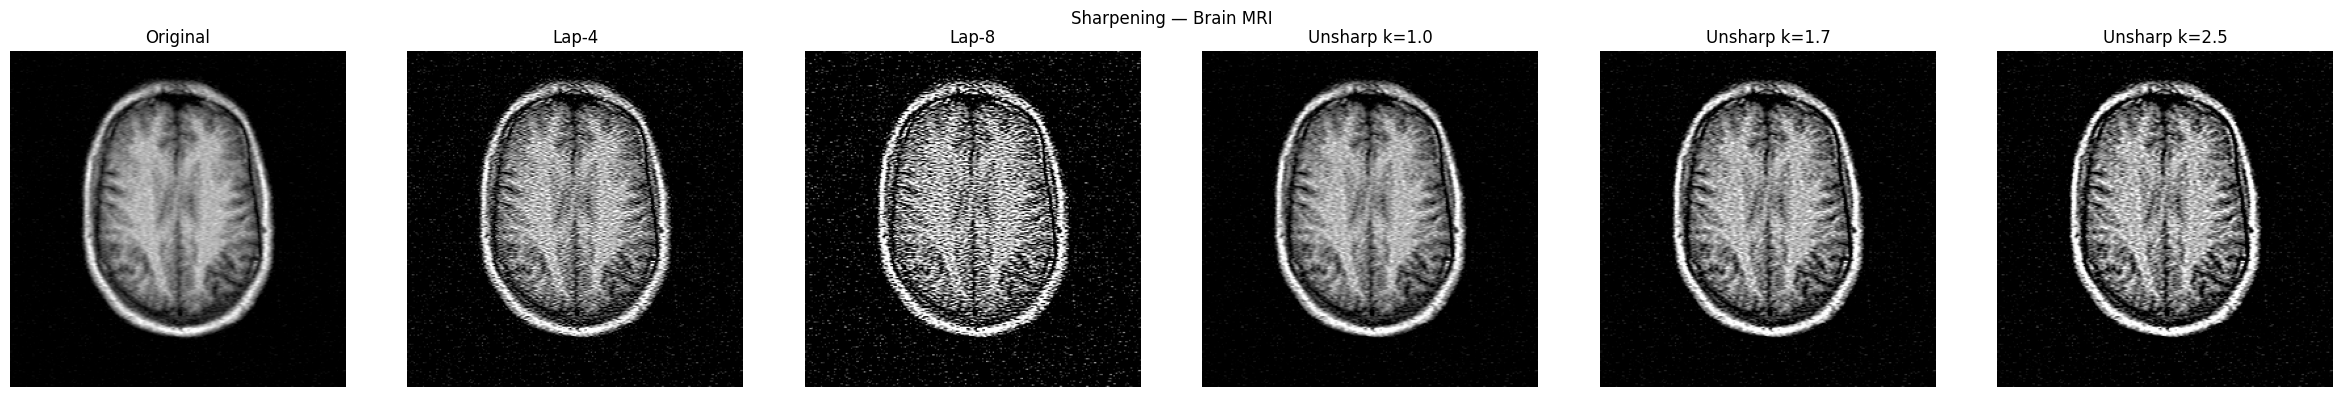

Noise                  Filter                    MSE  PSNR (dB)
────────────────────────────────────────────────────────────────
Gaussian               Box 7×7                325.52      23.01
Gaussian               Gauss σ=1.6            202.03      25.08
Gaussian               Median 5×5              98.46      28.20
Salt & Pepper          Box 7×7                341.94      22.79
Salt & Pepper          Gauss σ=1.6            229.21      24.53
Salt & Pepper          Median 5×5              64.89      30.01


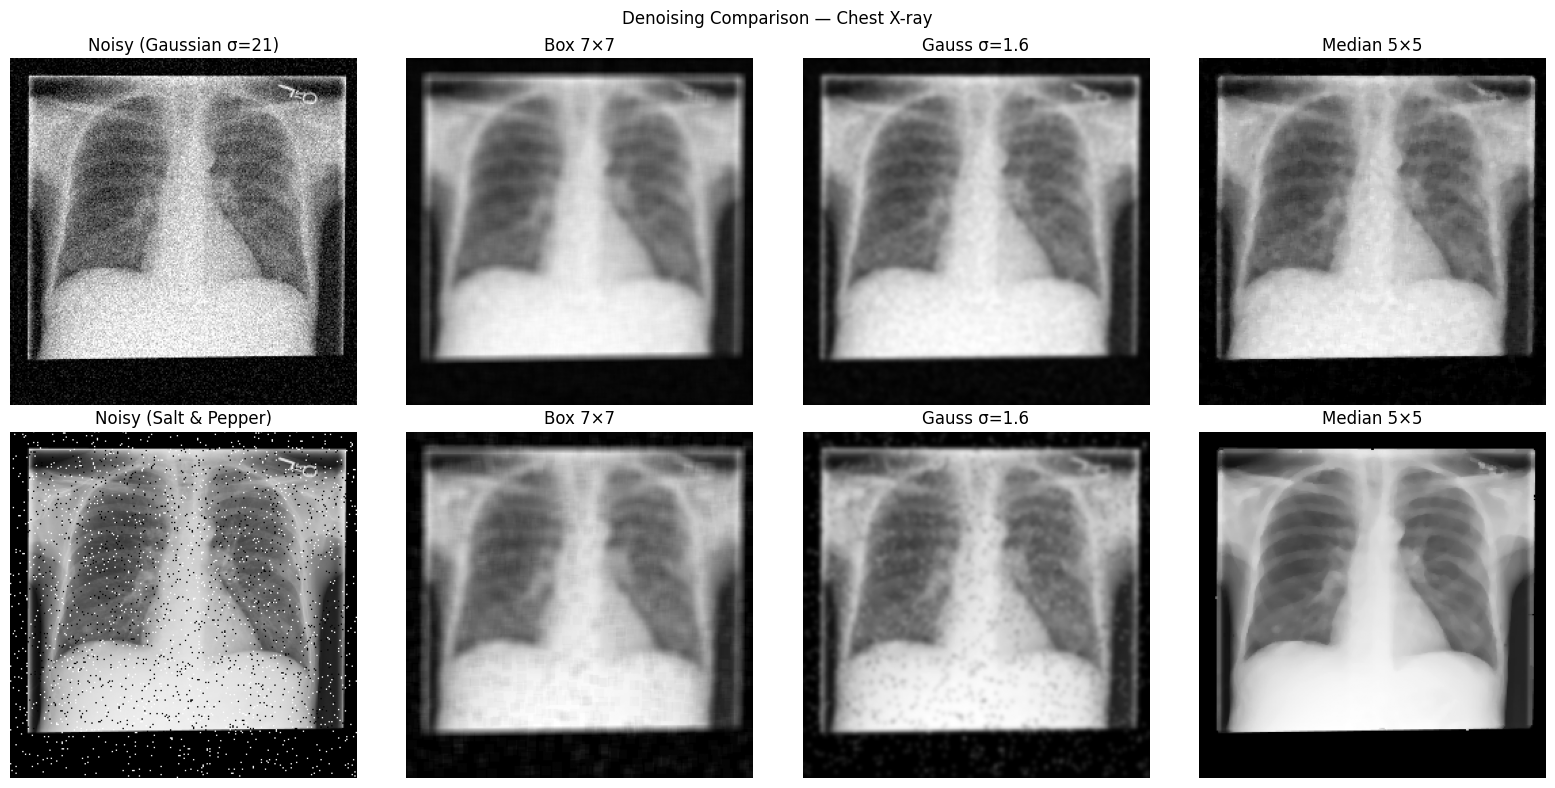

In [26]:
def add_gaussian_noise(image, sigma):
    """Add zero-mean Gaussian noise with std=sigma; clip to [0,255] and return uint8."""
    # Hint: noise = np.random.normal(0, sigma, image.shape)
    img = np.array(image, dtype=np.float64)
    noise = np.random.normal(0, sigma, img.shape)
    noisy = np.clip(img + noise, 0, 255)
    return noisy.astype(np.uint8)# YOUR CODE
    

def add_salt_pepper(image, density=0.05):
    """
    Add salt-and-pepper noise.
    Steps:
      1. n = int(density * image.size / 2)
      2. Pick n random row indices and n random col indices → set those pixels to 255 (salt)
      3. Pick n more random positions → set to 0 (pepper)
    Tip: np.random.randint(0, image.shape[0], n) for row indices
    """
    noisy = np.array(image, copy=True)
    n = int(density * noisy.size / 2)

    rows = np.random.randint(0, noisy.shape[0], n)
    cols = np.random.randint(0, noisy.shape[1], n)
    noisy[rows, cols] = 255

    rows = np.random.randint(0, noisy.shape[0], n)
    cols = np.random.randint(0, noisy.shape[1], n)
    noisy[rows, cols] = 0
    return noisy
    

def mse(original, result):
    """Mean Squared Error: average of (original - result)^2."""
    o = np.array(original, dtype=np.float64)
    r = np.array(result, dtype=np.float64)
    return float(np.mean((o - r) ** 2))
    

def psnr(original, result):
    """PSNR = 10 * log10(255^2 / MSE). Return float('inf') when MSE == 0."""
    m = mse(original, result)
    if m == 0:
        return float('inf')
    return float(10 * np.log10((255.0 ** 2) / m))



# ── Sharpening — Brain MRI (provided — do not modify) ─────────────────────────
brain_f = brain.astype(np.float64)
lap4 = np.array([[0, 1, 0], [1,-4, 1], [0, 1, 0]], dtype=np.float64)
lap8 = np.array([[1, 1, 1], [1,-8, 1], [1, 1, 1]], dtype=np.float64)

lap4_sharp = np.clip(brain_f - convolve2d(brain_f, lap4), 0, 255).astype(np.uint8)
lap8_sharp = np.clip(brain_f - convolve2d(brain_f, lap8), 0, 255).astype(np.uint8)

blur = convolve2d(brain_f, gaussian_kernel(MY_SIGMA))
ums  = {k: np.clip(brain_f + k * (brain_f - blur), 0, 255).astype(np.uint8)
        for k in [1.0, MY_K, 2.5]}

fig, axes = plt.subplots(1, 6, figsize=(24, 4))
for ax, img, title in zip(axes,
        [brain, lap4_sharp, lap8_sharp, ums[1.0], ums[MY_K], ums[2.5]],
        ['Original', 'Lap-4', 'Lap-8',
         'Unsharp k=1.0', f'Unsharp k={MY_K}', 'Unsharp k=2.5']):
    ax.imshow(img, cmap='gray'); ax.set_title(title); ax.axis('off')
plt.suptitle('Sharpening — Brain MRI'); plt.tight_layout(); plt.show()


# ── Denoising — Chest X-ray (provided — do not modify) ────────────────────────
from scipy.ndimage import median_filter   # allowed for median only
np.random.seed(42)
xray_gauss = add_gaussian_noise(xray, MY_NOISE)
xray_sp    = add_salt_pepper(xray, density=0.05)

def _denoise_box(img):
    return np.clip(convolve2d(img, box_kernel(MY_KERNEL)), 0, 255).astype(np.uint8)
def _denoise_gauss(img):
    return np.clip(convolve2d(img, gaussian_kernel(MY_SIGMA)), 0, 255).astype(np.uint8)
def _denoise_median(img):
    return median_filter(img, size=5)

filters = [
    (f'Box {MY_KERNEL}×{MY_KERNEL}', _denoise_box),
    (f'Gauss σ={MY_SIGMA}',          _denoise_gauss),
    ('Median 5×5',                   _denoise_median),
]

print(f"{'Noise':<22} {'Filter':<20} {'MSE':>8} {'PSNR (dB)':>10}")
print('─' * 64)
for noise_name, noisy in [('Gaussian', xray_gauss), ('Salt & Pepper', xray_sp)]:
    for fname, filt in filters:
        d = filt(noisy)
        print(f"{noise_name:<22} {fname:<20} {mse(xray, d):>8.2f} {psnr(xray, d):>10.2f}")

# Visual comparison
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for row, (noisy, noise_name) in enumerate([(xray_gauss, f'Gaussian σ={MY_NOISE}'),
                                            (xray_sp,   'Salt & Pepper')]):
    axes[row, 0].imshow(noisy, cmap='gray')
    axes[row, 0].set_title(f'Noisy ({noise_name})'); axes[row, 0].axis('off')
    for col, (fname, filt) in enumerate(filters, start=1):
        axes[row, col].imshow(filt(noisy), cmap='gray')
        axes[row, col].set_title(fname); axes[row, col].axis('off')
plt.suptitle('Denoising Comparison — Chest X-ray'); plt.tight_layout(); plt.show()


In [25]:
# ── Tests — DO NOT MODIFY ────────────────────────────────────────────────────
np.random.seed(0)

# mse: identical images -> 0
_a = np.zeros((10,10), dtype=np.uint8)
assert abs(mse(_a, _a)) < 1e-10, "mse of identical images must be 0"

# mse: known value
_b = np.ones((10,10), dtype=np.uint8) * 10
assert abs(mse(_a, _b) - 100.0) < 1e-6, f"mse incorrect: got {mse(_a,_b)}"

# psnr: must be positive and finite for different images
assert 0 < psnr(_a, _b) < float('inf'), "psnr must be positive finite"

# add_gaussian_noise: shape and dtype preserved, values changed
_noisy = add_gaussian_noise(xray, 20)
assert _noisy.shape == xray.shape, "Noisy image shape must match original"
assert _noisy.dtype == np.uint8,   "Noisy image must be uint8"
assert not np.array_equal(_noisy, xray), "Noise must change the image"
assert _noisy.min() >= 0 and _noisy.max() <= 255, "Values must stay in [0,255]"

# add_salt_pepper: shape preserved, has 0s and 255s
_sp = add_salt_pepper(xray, density=0.05)
assert _sp.shape == xray.shape, "Salt-pepper image shape must match original"
assert 0   in _sp, "Salt-pepper must contain 0 (pepper)"
assert 255 in _sp, "Salt-pepper must contain 255 (salt)"

# Gaussian filter must improve PSNR over noisy
_denoised = np.clip(convolve2d(_noisy, gaussian_kernel(MY_SIGMA)), 0, 255).astype(np.uint8)
assert psnr(xray, _denoised) > psnr(xray, _noisy),     "Gaussian filter should improve PSNR over noisy image"

print("Task 2.3 PASSED ✓")


Task 2.3 PASSED ✓


**Denoising Results:**

| Noise | Filter | MSE | PSNR (dB) |
|-------|--------|-----|-----------|
| Gaussian σ=`MY_NOISE` | Box `MY_KERNEL`×`MY_KERNEL` | 352.52 | 23.01 |
| Gaussian σ=`MY_NOISE` | Gaussian σ=`MY_SIGMA` | 202.03| 25.08 |
| Gaussian σ=`MY_NOISE` | Median 5×5 |98.46 | 28.20 |
| Salt & Pepper d=0.05 | Box `MY_KERNEL`×`MY_KERNEL` |341.49 | 22.79 |
| Salt & Pepper d=0.05 | Gaussian σ=`MY_SIGMA` | 229.21 | 24.53 |
| Salt & Pepper d=0.05 | Median 5×5 | 64.89  | 30.01 |

**Analysis:** *(1–2 sentences)*


For Gaussian noise, the median filter (5×5) showed the best performance in this experiment. Compared to box and Gaussian filters, it produced the lowest MSE (98.46) and the highest PSNR (28.20 dB). It removes a large portion of the noise while better preserving important anatomical features; the box filter, on the other hand, creates a strong blur.

For salt and pepper noise, the median filter (5×5) also yielded the best results. This is expected because median filtering is particularly effective for pulse noise, where individual pixels are randomly replaced with very bright or very dark values. The median process eliminates these outlier pixels while preserving edges. This is confirmed by the lowest MSE (64.89) and the highest PSNR (30.01 dB) among the filters tested. For these reasons, the median filter provides the best noise removal performance for both types of noise in these results, especially for salt and pepper noise.

---
## Part 3 — Frequency Domain Filtering (40 points)


### Task 3.1 — DFT Exploration (10 points)

For **both** images:
1. Compute 2D DFT and shift DC to centre
2. Display magnitude spectrum (log-scaled) and phase spectrum
3. Reconstruct from **magnitude only** (set phase to zero, inverse DFT)
4. Reconstruct from **phase only** (set magnitude to 1, inverse DFT)
5. Normalise reconstructions to [0, 255] and display all in a grid

**Analysis:** Which component carries more structural information? Does this differ between modalities?


In [ ]:
# ── Helper functions (provided — do not modify) ──────────────────────────────
def log_magnitude(F_shifted):
    """Return log-scaled magnitude for display."""
    return 20 * np.log10(1 + np.abs(F_shifted))

def normalize_to_uint8(arr):
    """Normalize a real-valued array to [0, 255] uint8."""
    arr = np.real(arr).astype(np.float64)
    lo, hi = arr.min(), arr.max()
    if hi == lo:
        return np.zeros_like(arr, dtype=np.uint8)
    return ((arr - lo) / (hi - lo) * 255).astype(np.uint8)

# ─────────────────────────────────────────────────────────────────────────────
# YOUR CODE: fill in the ... parts below
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for row, (img, name) in enumerate([(xray, 'X-ray'), (brain, 'Brain MRI')]):
    img_f = img.astype(np.float64)

    # Step 1: Compute 2D DFT and shift DC to centre
    F         = np.fft.fft2(...)       # YOUR CODE: compute 2D DFT of img_f
    F_shifted = np.fft.fftshift(...)   # YOUR CODE: shift DC to centre

    # Step 2: Magnitude and phase spectra
    axes[row, 0].imshow(log_magnitude(F_shifted), cmap='hot')
    axes[row, 0].set_title(f'{name}: Magnitude'); axes[row, 0].axis('off')
    axes[row, 1].imshow(np.angle(F_shifted), cmap='hsv')
    axes[row, 1].set_title(f'{name}: Phase'); axes[row, 1].axis('off')

    # Step 3: Reconstruct from magnitude only (throw away phase → set to 0)
    # Formula: F_mag_only = |F_shifted| * exp(j*0) = |F_shifted| + 0j
    F_mag_only    = ...                                 # YOUR CODE
    mag_recon     = np.real(np.fft.ifft2(np.fft.ifftshift(F_mag_only)))

    # Step 4: Reconstruct from phase only (set magnitude to 1)
    # Formula: F_phase_only = 1 * exp(j * angle(F_shifted)) = exp(j * angle)
    F_phase_only  = ...                                 # YOUR CODE
    phase_recon   = np.real(np.fft.ifft2(np.fft.ifftshift(F_phase_only)))

    # Step 5: Display reconstructions and original
    axes[row, 2].imshow(normalize_to_uint8(mag_recon),   cmap='gray')
    axes[row, 2].set_title(f'{name}: Mag-only'); axes[row, 2].axis('off')
    axes[row, 3].imshow(normalize_to_uint8(phase_recon), cmap='gray')
    axes[row, 3].set_title(f'{name}: Phase-only'); axes[row, 3].axis('off')
    axes[row, 4].imshow(img, cmap='gray')
    axes[row, 4].set_title(f'{name}: Original'); axes[row, 4].axis('off')

plt.tight_layout(); plt.show()


In [ ]:
# ── Tests — DO NOT MODIFY ────────────────────────────────────────────────────
_F  = np.fft.fft2(xray.astype(np.float64))
_Fs = np.fft.fftshift(_F)

# Magnitude-only reconstruction must be real after IFFT
_mag_only = np.fft.ifft2(np.fft.ifftshift(np.abs(_Fs)))
assert np.max(np.abs(np.imag(_mag_only))) < 1e-6,     "Magnitude-only IFFT should have negligible imaginary part"

# Phase-only reconstruction must have unit magnitude in freq domain
_phase_only_F = np.exp(1j * np.angle(_Fs))
assert np.allclose(np.abs(_phase_only_F), 1.0),     "Phase-only filter must have unit magnitude everywhere"

# Reconstructing from full F must give back original (up to floating point)
_reconstructed = np.real(np.fft.ifft2(_F))
assert np.max(np.abs(_reconstructed - xray.astype(np.float64))) < 1e-6,     "Full DFT roundtrip must recover original image"

print("Task 3.1 PASSED ✓")


**Analysis:** *(2–3 sentences)*


### Task 3.2 — Low-Pass Filtering (20 points)

Implement the four functions below, then apply all three LP filter types to `xray`.

| Filter | Variants |
|--------|----------|
| Ideal (ILPF) | D₀ = 20, `MY_D0_LP`, 100 |
| Butterworth (BLPF) | D₀ = `MY_D0_LP`, n = 1, `MY_N`, 4 |
| Gaussian (GLPF) | D₀ = 20, `MY_D0_LP`, 100 |

For each result display: filter mask — filtered image — filtered magnitude spectrum.

**Analysis:** Why does ILPF produce ringing and the others do not?


In [ ]:
def create_distance_matrix(shape):
    """
    Return a 2D array where each entry is the Euclidean distance from the DC centre.
    Steps:
      1. u = np.fft.fftfreq(shape[0]) * shape[0]   (row frequencies)
         v = np.fft.fftfreq(shape[1]) * shape[1]   (column frequencies)
      2. U, V = np.meshgrid(v, u)   ← note order
      3. D = np.sqrt(U**2 + V**2)
      4. Return np.fft.fftshift(D) so DC is at the centre
    """
    pass

def ilpf(shape, D0):
    """Ideal Low-Pass Filter: 1 inside D0, 0 outside."""
    # YOUR CODE — hint: (create_distance_matrix(shape) <= D0).astype(float)
    pass

def blpf(shape, D0, n):
    """Butterworth Low-Pass Filter: 1 / (1 + (D/D0)^(2n))"""
    # YOUR CODE
    pass

def glpf(shape, D0):
    """Gaussian Low-Pass Filter: exp(-D^2 / (2*D0^2))"""
    # YOUR CODE
    pass

def apply_freq_filter(image, H):
    """
    Apply frequency-domain filter H to image and return uint8 result.
    Steps:
      1. F = np.fft.fft2(image.astype(float))
      2. F_shifted = np.fft.fftshift(F)
      3. Multiply: G_shifted = F_shifted * H
      4. G = np.fft.ifftshift(G_shifted)
      5. g = np.real(np.fft.ifft2(G))
      6. Clip to [0,255] and return as uint8
    """
    pass


# ── Plotting code (provided — do not modify) ──────────────────────────────────
def _show_filter_result(ax_mask, ax_img, ax_spec, H, result, title):
    ax_mask.imshow(H, cmap='gray'); ax_mask.set_title(f'{title}: mask'); ax_mask.axis('off')
    ax_img.imshow(result, cmap='gray'); ax_img.set_title(f'{title}: filtered'); ax_img.axis('off')
    F = np.fft.fftshift(np.fft.fft2(result.astype(float)))
    ax_spec.imshow(log_magnitude(F), cmap='hot'); ax_spec.set_title(f'{title}: spectrum'); ax_spec.axis('off')

shape = xray.shape

# ILPF — 3 cutoff values
ilpf_variants = [(20, ilpf(shape, 20)), (MY_D0_LP, ilpf(shape, MY_D0_LP)), (100, ilpf(shape, 100))]
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for row, (D0, H) in enumerate(ilpf_variants):
    _show_filter_result(axes[row,0], axes[row,1], axes[row,2],
                        H, apply_freq_filter(xray, H), f'ILPF D₀={D0}')
plt.suptitle('Ideal Low-Pass Filter — Chest X-ray'); plt.tight_layout(); plt.show()

# BLPF — 3 order values
blpf_variants = [(1, blpf(shape, MY_D0_LP, 1)),
                 (MY_N, blpf(shape, MY_D0_LP, MY_N)),
                 (4,    blpf(shape, MY_D0_LP, 4))]
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for row, (n, H) in enumerate(blpf_variants):
    _show_filter_result(axes[row,0], axes[row,1], axes[row,2],
                        H, apply_freq_filter(xray, H), f'BLPF D₀={MY_D0_LP} n={n}')
plt.suptitle('Butterworth Low-Pass Filter — Chest X-ray'); plt.tight_layout(); plt.show()

# GLPF — 3 cutoff values
glpf_variants = [(20, glpf(shape, 20)), (MY_D0_LP, glpf(shape, MY_D0_LP)), (100, glpf(shape, 100))]
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for row, (D0, H) in enumerate(glpf_variants):
    _show_filter_result(axes[row,0], axes[row,1], axes[row,2],
                        H, apply_freq_filter(xray, H), f'GLPF D₀={D0}')
plt.suptitle('Gaussian Low-Pass Filter — Chest X-ray'); plt.tight_layout(); plt.show()


In [ ]:
# ── Tests — DO NOT MODIFY ────────────────────────────────────────────────────
_sh = (100, 100)
_D  = create_distance_matrix(_sh)

# Shape and symmetry
assert _D.shape == _sh,                          "create_distance_matrix: wrong shape"
assert _D[50, 50] == 0.0,                        "create_distance_matrix: DC centre must be 0"
assert _D[0, 0] > 0,                             "create_distance_matrix: corner must be > 0"
assert np.allclose(_D, _D[::-1, :]),             "create_distance_matrix: must be vertically symmetric"
assert np.allclose(_D, _D[:, ::-1]),             "create_distance_matrix: must be horizontally symmetric"

# ILPF: binary, DC=1, far corner=0
_H = ilpf(_sh, 30)
assert _H.shape == _sh,                          "ilpf: wrong shape"
assert _H[50, 50] == 1.0,                        "ilpf: DC must be 1"
assert _H[0, 0]   == 0.0,                        "ilpf: far corner must be 0"
assert set(np.unique(_H)).issubset({0.0, 1.0}), "ilpf: must be binary"

# BLPF: DC~1, decreases away, all in (0,1]
_H = blpf(_sh, 30, 2)
assert abs(_H[50, 50] - 1.0) < 1e-6,            "blpf: DC must be ~1"
assert 0 < _H[0, 0] < 0.5,                      "blpf: far corner must be < 0.5"
assert _H.min() > 0 and _H.max() <= 1.0,        "blpf: values must be in (0,1]"

# GLPF: DC=1, strictly decreasing outward
_H = glpf(_sh, 30)
assert abs(_H[50, 50] - 1.0) < 1e-6,            "glpf: DC must be ~1"
assert 0 < _H[0, 0] < _H[50, 50],               "glpf: must decrease away from centre"

# apply_freq_filter: all-ones filter is near-identity
_ones = np.ones(xray.shape)
_out  = apply_freq_filter(xray, _ones)
assert _out.shape == xray.shape,                 "apply_freq_filter: wrong output shape"
assert _out.dtype == np.uint8,                   "apply_freq_filter: must return uint8"
assert np.mean(np.abs(_out.astype(float) - xray.astype(float))) < 1.0,     "apply_freq_filter: all-ones filter should be near-identity"

# Low D0 must produce a blurrier image than high D0
_blur_lo = apply_freq_filter(xray, ilpf(xray.shape, 10))
_blur_hi = apply_freq_filter(xray, ilpf(xray.shape, 80))
assert psnr(xray, _blur_hi) > psnr(xray, _blur_lo),     "Higher D0 should preserve more detail (higher PSNR)"

print("Task 3.2 PASSED ✓")


**Analysis:** *(2–3 sentences)*


### Task 3.3 — High-Pass Filtering & Domain Comparison (10 points)

1. Derive HP filters using $H_{HP} = 1 - H_{LP}$. Apply Ideal, Butterworth (n=`MY_N`), and Gaussian HP to `brain` with D₀=`MY_D0_HP`. Display mask and result for each.
2. Build and apply the HFE filter using the formula in the Background section.
3. Add Gaussian noise (σ=`MY_NOISE`) to `brain`, then denoise with:
   - Spatial Gaussian (σ=`MY_SIGMA`, your `convolve2d`)
   - Frequency GLPF (D₀=`MY_D0_LP`, your `apply_freq_filter`)

   Compute PSNR for both and display side by side.

**Analysis:** Which gives better PSNR? Does that match what you see visually?


In [ ]:
shape = brain.shape

# ── 1. HP filters (YOUR CODE) ────────────────────────────────────────────────
# Derive HP from LP using H_HP = 1 - H_LP
H_ilpf_hp  = None  # YOUR CODE: 1 - ilpf(shape, MY_D0_HP)
H_blpf_hp  = None  # YOUR CODE: 1 - blpf(shape, MY_D0_HP, MY_N)
H_glpf_hp  = None  # YOUR CODE: 1 - glpf(shape, MY_D0_HP)

# ── 2. HFE filter (YOUR CODE) ────────────────────────────────────────────────
# Formula: H_hfe = 0.5 + 2.0 * H_blpf_hp
H_hfe = None  # YOUR CODE

# ── HP & HFE display (provided — do not modify) ──────────────────────────────
hp_filters = [
    ('ILPF HP', H_ilpf_hp),
    ('BLPF HP', H_blpf_hp),
    ('GLPF HP', H_glpf_hp),
    ('HFE',     H_hfe),
]
fig, axes = plt.subplots(4, 2, figsize=(8, 16))
for row, (name, H) in enumerate(hp_filters):
    axes[row, 0].imshow(H, cmap='gray')
    axes[row, 0].set_title(f'{name}: mask'); axes[row, 0].axis('off')
    axes[row, 1].imshow(apply_freq_filter(brain, H), cmap='gray')
    axes[row, 1].set_title(f'{name}: result'); axes[row, 1].axis('off')
plt.suptitle(f'High-Pass & HFE Filters — Brain MRI (D₀={MY_D0_HP})')
plt.tight_layout(); plt.show()


# ── 3. Domain comparison (YOUR CODE) ─────────────────────────────────────────
np.random.seed(0)
brain_noisy = add_gaussian_noise(brain, MY_NOISE)

# Spatial denoising with your convolve2d + gaussian_kernel
brain_spatial = None  # YOUR CODE: np.clip(convolve2d(...), 0, 255).astype(np.uint8)

# Frequency denoising with apply_freq_filter + glpf
brain_freq    = None  # YOUR CODE: apply_freq_filter(brain_noisy, glpf(shape, MY_D0_LP))

# ── Domain comparison display (provided — do not modify) ─────────────────────
psnr_spatial = psnr(brain, brain_spatial)
psnr_freq    = psnr(brain, brain_freq)
print(f"PSNR — Spatial Gaussian (σ={MY_SIGMA}):  {psnr_spatial:.2f} dB")
print(f"PSNR — Freq GLPF (D₀={MY_D0_LP}):        {psnr_freq:.2f} dB")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img, title in zip(axes,
        [brain, brain_noisy, brain_spatial, brain_freq],
        ['Original', f'Noisy σ={MY_NOISE}',
         f'Spatial σ={MY_SIGMA}\nPSNR={psnr_spatial:.1f}dB',
         f'Freq D₀={MY_D0_LP}\nPSNR={psnr_freq:.1f}dB']):
    ax.imshow(img, cmap='gray'); ax.set_title(title); ax.axis('off')
plt.suptitle('Spatial vs Frequency Denoising — Brain MRI')
plt.tight_layout(); plt.show()


In [ ]:
# ── Tests — DO NOT MODIFY ────────────────────────────────────────────────────
_sh = brain.shape

# HP = 1 - LP
_lp = glpf(_sh, MY_D0_HP)
_hp = 1 - _lp
assert np.allclose(_hp + _lp, 1.0), "HP + LP must equal 1 everywhere"
assert _hp[_sh[0]//2, _sh[1]//2] < 0.01, "HP: DC (centre) must be ~0"

# HFE must be >= LP everywhere (adds energy to high freqs)
_bhp = 1 - blpf(_sh, MY_D0_HP, MY_N)
_hfe = 0.5 + 2.0 * _bhp
assert _hfe.min() >= 0.5,        "HFE minimum must be >= 0.5"
assert _hfe[_sh[0]//2, _sh[1]//2] < 1.0, "HFE: DC must be < 1 (suppressed)"

# Domain comparison: both methods should improve PSNR over noisy
np.random.seed(0)
_noisy = add_gaussian_noise(brain, MY_NOISE)
_sp = np.clip(convolve2d(_noisy, gaussian_kernel(MY_SIGMA)), 0, 255).astype(np.uint8)
_fp = apply_freq_filter(_noisy, glpf(brain.shape, MY_D0_LP))
assert psnr(brain, _sp) > psnr(brain, _noisy), "Spatial Gaussian must improve PSNR"
assert psnr(brain, _fp) > psnr(brain, _noisy), "Freq GLPF must improve PSNR"

print("Task 3.3 PASSED ✓")


**Analysis:** *(1–2 sentences)*


---
## Part 4 — Clinical Discussion (15 points)

A radiologist reviews low-dose chest X-rays for 5–10 mm lung nodules. The images contain moderate Gaussian noise.

Recommend a filtering pipeline using your results from Parts 2 and 3. Your answer must:
- Reference at least two PSNR/MSE values from your tables
- Justify spatial vs. frequency domain choice (or both)
- Identify one risk of over-filtering in this clinical context

*(~150 words)*


**Answer:** *Write here.*


---
## Bonus — Notch Filter (10 points)

1. Add periodic noise (code provided — do not modify)
2. Compute and display the magnitude spectrum — locate the two noise peaks
3. Design a notch reject filter that zeroes out only the two peak regions
4. Apply the filter and display: noisy | spectrum | mask | restored
5. Compute and print PSNR before and after filtering


In [ ]:
# Step 1 — DO NOT MODIFY
cols = np.arange(256)
noisy_periodic = np.clip(xray.astype(float) + 30*np.sin(2*np.pi*0.1*cols), 0, 255).astype(np.uint8)

# Step 2: Compute and display the noisy magnitude spectrum, annotate peaks

# Step 3: Build the notch reject filter

# Step 4: Apply filter and display results

# Step 5: Print PSNR


**Analysis:** *(note peak locations, filter design, achieved PSNR)*


---
## Submission Checklist

- [ ] `STUDENT_ID` set and parameters printed
- [ ] All cells run without errors (Kernel → Restart & Run All)
- [ ] All test cells print `PASSED ✓`
- [ ] Results tables filled with actual values
- [ ] All analysis cells answered (not placeholder text)
- [ ] Minimum 5 meaningful commits on GitHub Classroom

---
*BMM411 — Spring 2025/2026 — Ogr. Gor. Mertcan Ozdemir*
